<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stress and Strain — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lectures 4 & 5 — Stress and Strain**

This notebook builds up, in code, everything derived analytically in lecture:

1. **Stress** — traction, principal stresses, Mohr's circle, deviatoric stress
2. **Strain** — the displacement gradient, strain/rotation decomposition, principal strains, dilatation
3. **A propagating seismic wave** — a numeric check of the analytic maximum-shear-strain result
4. **Real-world strain estimation** — a simple constant-strain-triangle example from synthetic GNSS-like station data
5. **Linear elasticity** — Lamé parameters, the isotropic stress-strain relation, and a full elastic-moduli calculator

It extends a short earlier notebook that found principal stress axes by a brute-force grid search over rotation angles — we start there, then show the much faster eigenvalue approach, and confirm the two agree.

## 0. Setup

In [22]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (7, 5)

## Part 1 — Stress

### 1.1 Traction on an arbitrary plane

We'll use the worked example from lecture: a 2-D stress tensor and a fault oriented 45° clockwise from the x-axis.

In [23]:
T = np.array([[-40, -10],
              [-10, -60]])   # stress tensor, MPa

n_hat = np.array([1, 1]) / np.sqrt(2)   # fault unit normal

traction = T @ n_hat
print("Traction vector:", traction, "MPa")

Traction vector: [-35.35533906 -49.49747468] MPa


In [24]:
# Decompose into normal and shear components
s_hat = np.array([-n_hat[1], n_hat[0]])   # unit tangent, perpendicular to n_hat

t_normal = traction @ n_hat
t_shear = traction @ s_hat
print(f"Normal traction (compression if negative): {t_normal:.2f} MPa")
print(f"Shear traction: {t_shear:.2f} MPa")

Normal traction (compression if negative): -60.00 MPa
Shear traction: -10.00 MPa


### 1.2 Principal stresses — the brute-force way

Before reaching for `numpy.linalg.eig`, it's worth seeing *why* it works. The principal axes are the orientation where the shear stress on the rotated tensor vanishes. We can find this by literally rotating the tensor through every angle from 0° to 180° and looking for where the shear component crosses zero — exactly the approach in the original course notebook this one builds on.

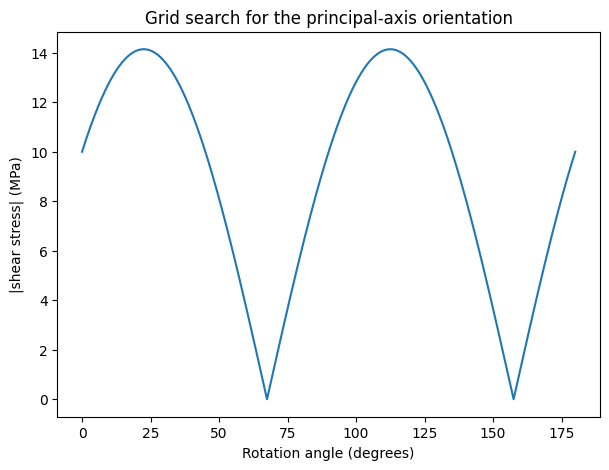

In [25]:
angles = np.linspace(0, 180, num=1801)   # 0.1-degree resolution
shear = np.zeros(len(angles))

for i, ang in enumerate(angles):
    theta = np.deg2rad(ang)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    T_rot = R.T @ T @ R
    shear[i] = T_rot[0, 1]

plt.plot(angles, np.abs(shear))
plt.xlabel("Rotation angle (degrees)")
plt.ylabel("|shear stress| (MPa)")
plt.title("Grid search for the principal-axis orientation")
plt.show()

In [26]:
# The principal orientation is where shear is (near) zero
best = np.argmin(np.abs(shear))
print(f"Principal axis orientation ≈ {angles[best]:.1f}°")

Principal axis orientation ≈ 157.5°


### 1.3 Principal stresses — the fast way

`numpy.linalg.eig` solves the same eigenvalue problem directly and gives both the principal stresses (eigenvalues) and principal directions (eigenvectors) in one call. Let's confirm it agrees with the grid search and with the analytic result from lecture (λ₁ = -35.86 MPa, λ₂ = -64.14 MPa).

In [27]:
eigvals, eigvecs = np.linalg.eig(T)
print("Principal stresses (eigenvalues):", np.round(eigvals, 2))
print("Principal directions (eigenvectors, as columns):\n", np.round(eigvecs, 4))

# angle of the first eigenvector from the x-axis
angle0 = np.rad2deg(np.arctan2(eigvecs[1, 0], eigvecs[0, 0])) % 180
print(f"First principal direction ≈ {angle0:.1f}° from the x-axis")

Principal stresses (eigenvalues): [-35.86 -64.14]
Principal directions (eigenvectors, as columns):
 [[ 0.9239  0.3827]
 [-0.3827  0.9239]]
First principal direction ≈ 157.5° from the x-axis


In [28]:
# Verify: the rotated tensor N^T T N should be diagonal
T_principal = eigvecs.T @ T @ eigvecs
print("Rotated (principal-axis) stress tensor:\n", np.round(T_principal, 2))

Rotated (principal-axis) stress tensor:
 [[-35.86   0.  ]
 [  0.   -64.14]]


### 1.4 Mohr's circle as a reusable function

Rather than re-deriving Mohr's circle by hand for every problem, we can write one function that works for any 2-D stress tensor.

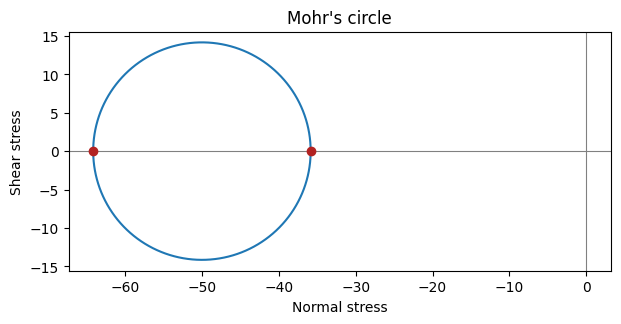

Center = -50.00 MPa, radius (max shear) = 14.14 MPa


In [29]:
def mohr_circle(T, ax=None):
    """Plot Mohr's circle for a 2x2 stress tensor T."""
    eigvals, _ = np.linalg.eig(T)
    center = eigvals.mean()
    radius = abs(eigvals[0] - eigvals[1]) / 2

    theta = np.linspace(0, 2 * np.pi, 300)
    normal = center + radius * np.cos(theta)
    shear = radius * np.sin(theta)

    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(normal, shear)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.plot(eigvals, [0, 0], "o", color="firebrick")
    ax.set_xlabel("Normal stress")
    ax.set_ylabel("Shear stress")
    ax.set_title("Mohr's circle")
    ax.set_aspect("equal")
    return center, radius

center, radius = mohr_circle(T)
plt.show()
print(f"Center = {center:.2f} MPa, radius (max shear) = {radius:.2f} MPa")

### 1.5 Deviatoric stress

The deviatoric stress removes the mean (hydrostatic) normal stress, isolating the part of the stress tensor that actually distorts the material.

In [30]:
def deviatoric_stress(T):
    mean_stress = np.trace(T) / T.shape[0]
    return T - mean_stress * np.eye(T.shape[0])

T_dev = deviatoric_stress(T)
print("Mean stress:", np.trace(T) / 2, "MPa")
print("Deviatoric stress tensor:\n", T_dev)

Mean stress: -50.0 MPa
Deviatoric stress tensor:
 [[ 10. -10.]
 [-10. -10.]]


## Part 2 — Strain

### 2.1 From a displacement gradient to strain and rotation

Given a displacement gradient tensor J (in practice, estimated from real station data — see Part 4), split it into the symmetric strain tensor and antisymmetric rotation tensor.

In [31]:
J = np.array([[0.5e-6, 1.2e-6],
              [0.3e-6, -0.2e-6]])   # displacement gradient tensor (unitless, e.g. strain/rotation rates per unit time)

strain = 0.5 * (J + J.T)
rotation = 0.5 * (J - J.T)

print("Strain tensor (symmetric):\n", strain)
print("Rotation tensor (antisymmetric):\n", rotation)

Strain tensor (symmetric):
 [[ 5.0e-07  7.5e-07]
 [ 7.5e-07 -2.0e-07]]
Rotation tensor (antisymmetric):
 [[ 0.0e+00  4.5e-07]
 [-4.5e-07  0.0e+00]]


In [32]:
dilatation = np.trace(strain)
print(f"Dilatation (volume change): {dilatation:.3e}")

Dilatation (volume change): 3.000e-07


### 2.2 Principal strains

Exactly the same eigenvalue approach used for stress applies to the strain tensor.

In [33]:
e_vals, e_vecs = np.linalg.eig(strain)
print("Principal strains:", e_vals)
print("Principal strain directions:\n", e_vecs)

# 2-D closed-form check
e11, e22, e12 = strain[0, 0], strain[1, 1], strain[0, 1]
e_analytic = (e11 + e22) / 2 + np.array([1, -1]) * np.sqrt(((e11 - e22) / 2)**2 + e12**2)
print("Analytic 2-D formula gives:", e_analytic)

Principal strains: [ 9.77647268e-07 -6.77647268e-07]
Principal strain directions:
 [[ 0.84347065 -0.53717527]
 [ 0.53717527  0.84347065]]
Analytic 2-D formula gives: [ 9.77647268e-07 -6.77647268e-07]


### 2.3 Extension induces shear in a rotated frame

A quick demonstration that a strain tensor purely extensional in one frame acquires an off-diagonal (shear) term when expressed in a rotated frame — the same physical strain, described in different coordinates.

In [34]:
e_x = np.array([[3e-6, 0],
                 [0, 0]])   # pure extension along x

def rotate_tensor(T, degrees):
    theta = np.deg2rad(degrees)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    return R.T @ T @ R

for ang in [0, 15, 30, 45]:
    T_rot = rotate_tensor(e_x, ang)
    print(f"{ang:>3}° rotation -> e11={T_rot[0,0]:.2e}  e22={T_rot[1,1]:.2e}  e12={T_rot[0,1]:.2e}")

  0° rotation -> e11=3.00e-06  e22=0.00e+00  e12=0.00e+00
 15° rotation -> e11=2.80e-06  e22=2.01e-07  e12=-7.50e-07
 30° rotation -> e11=2.25e-06  e22=7.50e-07  e12=-1.30e-06
 45° rotation -> e11=1.50e-06  e22=1.50e-06  e12=-1.50e-06


Notice the shear component e12 grows from zero as the frame rotates away from the principal axes, peaking at 45° — and the trace (e11 + e22) stays constant at every angle, exactly as expected for a rotation-invariant quantity.

## Part 3 — Strain of a Propagating Seismic Wave

A numeric check of the analytic result from lecture: for a shear wave $u_z = A\sin[2\pi f(t - x/c)]$, the maximum shear strain is $2\pi f A / c$.

In [35]:
A, f, c = 1e-3, 2.0, 3.14e3   # 1 mm amplitude, 2 Hz, 3.14 km/s -> SI units (m, s)

def uz(x, t):
    return A * np.sin(2 * np.pi * f * (t - x / c))

x = np.linspace(0, 10, 5000)
dudx = np.gradient(uz(x, t=0), x)   # finite-difference spatial derivative

print(f"Max shear strain (numeric, finite difference): {np.max(np.abs(dudx)):.3e}")
print(f"Max shear strain (analytic, 2πfA/c):          {2*np.pi*f*A/c:.3e}")

Max shear strain (numeric, finite difference): 4.002e-06
Max shear strain (analytic, 2πfA/c):          4.002e-06


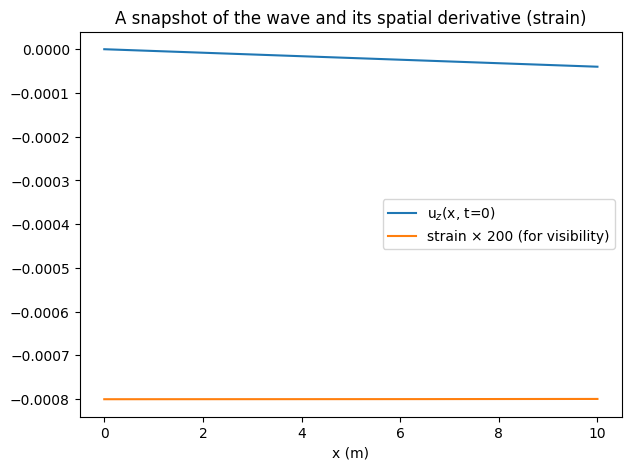

In [36]:
plt.plot(x, uz(x, t=0), label="u$_z$(x, t=0)")
plt.plot(x, dudx * 200, label="strain × 200 (for visibility)")
plt.xlabel("x (m)")
plt.legend()
plt.title("A snapshot of the wave and its spatial derivative (strain)")
plt.show()

## Part 4 — Estimating Strain from Real Station Networks

In practice you rarely have an analytic displacement field — you have discrete GNSS station positions and displacements. Here we build a small synthetic network and estimate strain with the **constant strain triangle** method described in lecture: for any 3 stations, there's a unique uniform strain tensor consistent with their relative displacements.

In [37]:
# Three synthetic GNSS stations forming a triangle, with displacements (m)
# consistent with a known "true" uniform strain field, so we can check our answer.
true_strain = np.array([[2e-6, 1e-6],
                         [1e-6, -1e-6]])

stations = np.array([[0.0, 0.0],
                      [10000.0, 0.0],
                      [3000.0, 8000.0]])   # station positions, meters

# Displacements consistent with u = true_strain @ x (no translation or rotation)
displacements = (true_strain @ stations.T).T
print("Station positions (m):\n", stations)
print("Displacements (m):\n", displacements)

Station positions (m):
 [[    0.     0.]
 [10000.     0.]
 [ 3000.  8000.]]
Displacements (m):
 [[ 0.     0.   ]
 [ 0.02   0.01 ]
 [ 0.014 -0.005]]


In [38]:
def constant_strain_triangle(stations, displacements):
    """Solve for the uniform displacement gradient tensor J over a 3-station triangle.

    For 3 points we have 6 displacement values (u_x, u_y at each station) and
    6 unknowns in J (a 2x2 matrix has 4 entries, but we solve directly via a
    linear least-squares system relating relative positions to relative
    displacements).
    """
    # Use station 0 as the reference; solve for J such that
    # displacements[i] - displacements[0] = J @ (stations[i] - stations[0])
    dX = (stations[1:] - stations[0]).T     # 2x2: relative positions
    dU = (displacements[1:] - displacements[0]).T   # 2x2: relative displacements
    J = dU @ np.linalg.inv(dX)
    return J

J_est = constant_strain_triangle(stations, displacements)
strain_est = 0.5 * (J_est + J_est.T)
print("Recovered displacement gradient J:\n", J_est)
print("Recovered strain tensor:\n", strain_est)
print("True strain tensor:\n", true_strain)

Recovered displacement gradient J:
 [[ 2.e-06  1.e-06]
 [ 1.e-06 -1.e-06]]
Recovered strain tensor:
 [[ 2.e-06  1.e-06]
 [ 1.e-06 -1.e-06]]
True strain tensor:
 [[ 2.e-06  1.e-06]
 [ 1.e-06 -1.e-06]]


The recovered strain matches the true strain exactly here because the synthetic data has no noise — with real GNSS data you'd see scatter, and this is exactly where the gridded-inversion and forward-modeling approaches from lecture start to outperform a single triangle.

## Part 5 — Linear Elasticity

### 5.1 The isotropic stress-strain relation

Given Lamé parameters λ and μ, apply $\tau_{ij} = \lambda\delta_{ij}e_{kk} + 2\mu e_{ij}$ directly to a strain tensor to get the corresponding stress tensor.

In [39]:
def stress_from_strain(e, lam, mu):
    """Isotropic linear-elastic stress-strain relation."""
    dilatation = np.trace(e)
    return lam * dilatation * np.eye(e.shape[0]) + 2 * mu * e

# Using the strain tensor recovered above, with typical crustal Lame parameters
lam, mu = 30e9, 30e9   # Pa ("Poisson solid": lambda = mu)
stress = stress_from_strain(strain_est, lam, mu)
print("Stress tensor (Pa):\n", stress)

Stress tensor (Pa):
 [[150000.  60000.]
 [ 60000. -30000.]]


### 5.2 Elastic moduli calculator

Given Lamé parameters and density, compute every other common elastic modulus and seismic velocity in one pass.

In [40]:
def elastic_moduli(lam, mu, rho):
    """Return Young's modulus, bulk modulus, Poisson's ratio, and Vp/Vs."""
    E = mu * (3 * lam + 2 * mu) / (lam + mu)
    kappa = lam + 2 / 3 * mu
    sigma = lam / (2 * (lam + mu))
    alpha = np.sqrt((lam + 2 * mu) / rho)   # Vp
    beta = np.sqrt(mu / rho)                # Vs
    return {"E": E, "kappa": kappa, "sigma": sigma, "Vp": alpha, "Vs": beta}

# "Poisson solid": lambda = mu = 30 GPa, rho = 2700 kg/m^3 (typical upper crust)
moduli = elastic_moduli(30e9, 30e9, 2700)
for k, v in moduli.items():
    print(f"{k:>6} = {v:.4g}")

     E = 7.5e+10
 kappa = 5e+10
 sigma = 0.25
    Vp = 5774
    Vs = 3333


In [41]:
# Sanity check: for a Poisson solid (lambda = mu), Poisson's ratio should be exactly 0.25
assert abs(moduli["sigma"] - 0.25) < 1e-10
print("Poisson-solid check passed: sigma =", moduli["sigma"])

# And the classic Vp/Vs ratio for a Poisson solid is sqrt(3)
print("Vp/Vs =", moduli["Vp"] / moduli["Vs"], " (expected sqrt(3) =", np.sqrt(3), ")")

Poisson-solid check passed: sigma = 0.25
Vp/Vs = 1.7320508075688772  (expected sqrt(3) = 1.7320508075688772 )


### 5.3 Exploring the parameter space

How do Vp, Vs, and Poisson's ratio vary as we move away from the Poisson-solid special case?

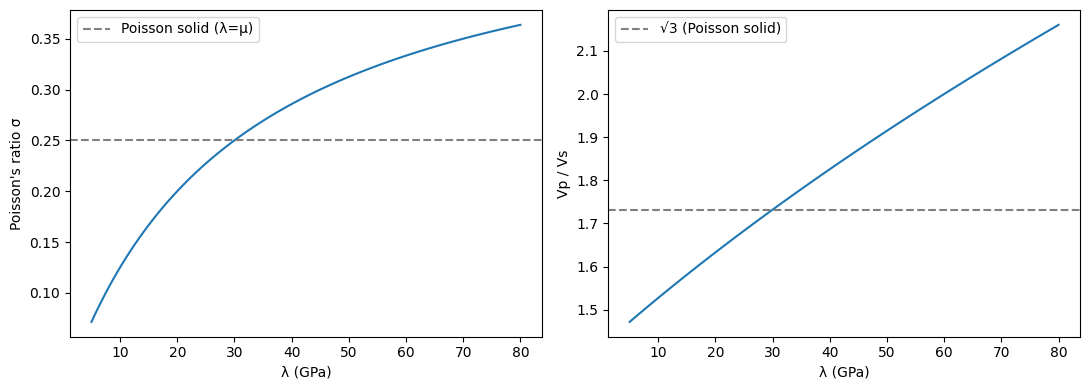

In [42]:
mu_fixed = 30e9
lam_range = np.linspace(5e9, 80e9, 100)

sigmas = [elastic_moduli(lam, mu_fixed, 2700)["sigma"] for lam in lam_range]
vp_vs_ratios = [elastic_moduli(lam, mu_fixed, 2700)["Vp"] / elastic_moduli(lam, mu_fixed, 2700)["Vs"] for lam in lam_range]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lam_range / 1e9, sigmas)
axes[0].axhline(0.25, color="gray", linestyle="--", label="Poisson solid (λ=μ)")
axes[0].set_xlabel("λ (GPa)"); axes[0].set_ylabel("Poisson's ratio σ")
axes[0].legend()

axes[1].plot(lam_range / 1e9, vp_vs_ratios)
axes[1].axhline(np.sqrt(3), color="gray", linestyle="--", label="√3 (Poisson solid)")
axes[1].set_xlabel("λ (GPa)"); axes[1].set_ylabel("Vp / Vs")
axes[1].legend()
plt.tight_layout()
plt.show()

## Summary & Further Resources

- **Stress** — `numpy.linalg.eig` for principal stresses/directions; Mohr's circle for a graphical view; remove the mean stress for the deviatoric part.
- **Strain** — split any displacement gradient into symmetric (strain) and antisymmetric (rotation) parts with `0.5*(J+J.T)` / `0.5*(J-J.T)`.
- **Real networks** — the constant strain triangle turns 3 stations' worth of displacements into a single uniform strain tensor; production tools (e.g. Crowell et al.'s [PyTAGS](https://github.com/crowellbw/PyTAGS)) extend this to gridded, distance-weighted inversions across many stations.
- **Elasticity** — two Lamé parameters (or any equivalent pair — E, κ, σ) plus density fully determine an isotropic elastic medium's stress-strain behavior and seismic velocities.

**For further reading on the geodesy/tectonics side:**
- UNAVCO/EarthScope's GAGE Facility geodetic strain-rate products: https://www.unavco.org/
- The Nevada Geodetic Laboratory's GNSS velocity/strain-rate maps: http://geodesy.unr.edu/
- Crowell et al. (2013), *Imperial Valley strain rates from combined geodetic data* — the dilatation figure shown in lecture.
- Crowell et al. (2009) — the Tokachi-oki GEONET triangulated-strain example shown in lecture.
- Turcotte, D. L., and G. Schubert, *Geodynamics*, for the continuum-mechanics foundations used throughout this notebook.